# AI Risk Manager
## 02 - Data Preprocessing

This notebook prepares the dataset for machine learning.

The preprocessing pipeline will be designed to avoid data leakage and
to preserve a completely held-out test set for final evaluation.

### Planned steps

1. Load the original dataset
2. Handle exact duplicate records
3. Separate features and target
4. Create a stratified train/test split
5. Prepare preprocessing using training data only
6. Prepare the data for model experiments

## 1. Load Original Dataset

We load the original dataset again rather than modifying the dataset
used during exploratory analysis.

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [22]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

Duplicate rows: 1081
Missing values: 0


## 2. Duplicate Impact Analysis

Exact duplicate rows were identified during EDA.

Before removing them, we measure their impact on:

- dataset size
- legitimate transactions
- fraudulent transactions

This prevents us from making a preprocessing decision without
understanding its effect on the target distribution.

In [23]:
df_no_duplicates = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("After removing exact duplicates:", df_no_duplicates.shape)

print("\nOriginal class distribution:")
print(df["Class"].value_counts().sort_index())

print("\nClass distribution after removing duplicates:")
print(df_no_duplicates["Class"].value_counts().sort_index())

print("\nRows removed:", len(df) - len(df_no_duplicates))

Original dataset shape: (284807, 31)
After removing exact duplicates: (283726, 31)

Original class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution after removing duplicates:
Class
0    283253
1       473
Name: count, dtype: int64

Rows removed: 1081


In [24]:
removed_rows = df[~df.index.isin(df_no_duplicates.index)]

print("Removed rows by class:")
print(removed_rows["Class"].value_counts().sort_index())

Removed rows by class:
Class
0    1062
1      19
Name: count, dtype: int64


## 3. Remove Exact Duplicate Records

Exact duplicate rows are removed before splitting the data.

This ensures that identical observations are not unnecessarily repeated
during model training and evaluation.

We only remove exact duplicates. We do not remove legitimate transactions
simply because they have similar values.

In [25]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


## 4. Separate Features and Target

The target variable is `Class`.

- `Class = 0` → Legitimate transaction
- `Class = 1` → Fraudulent transaction

All remaining variables will initially be treated as candidate input
features.

The target variable must not be included among the model features.

In [26]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Feature shape: (283726, 30)
Target shape: (283726,)

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


## 5. Stratified Train-Test Split

We divide the dataset into:

- 80% training data
- 20% held-out test data

Stratification is used because fraud is a rare class. It helps preserve
approximately the same fraud-to-legitimate ratio in both datasets.

The test set will remain untouched during model training, model
selection and threshold optimization.

It will only be used for final evaluation.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (226980, 30)
Test set: (56746, 30)

Training class distribution:
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Test class distribution:
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


## 6. Verify Stratified Split

Because fraud is a highly imbalanced class, we verify that the
training and held-out test sets contain similar class proportions.

The held-out test set must remain representative of the original
dataset.

In [28]:
split_check = pd.DataFrame({
    "Dataset": ["Full Dataset", "Training Set", "Test Set"],
    "Total Transactions": [
        len(y),
        len(y_train),
        len(y_test)
    ],
    "Fraud Transactions": [
        (y == 1).sum(),
        (y_train == 1).sum(),
        (y_test == 1).sum()
    ],
    "Fraud Rate (%)": [
        (y == 1).mean() * 100,
        (y_train == 1).mean() * 100,
        (y_test == 1).mean() * 100
    ]
})

split_check

,Dataset,Total Transactions,Fraud Transactions,Fraud Rate (%)
0,Full Dataset,283726,473,0.166710
1,Training Set,226980,378,0.166534
2,Test Set,56746,95,0.167413


## 7. Feature Data Types

All model input variables in this dataset are numerical.

We verify the data types before creating the preprocessing pipeline.

The target variable `Class` has already been separated and is not part
of the feature matrix.

In [29]:
print("Training feature data types:")
print(X_train.dtypes.value_counts())

print("\nNon-numeric columns:")
print(X_train.select_dtypes(exclude=np.number).columns.tolist())

Training feature data types:
float64    30
Name: count, dtype: int64

Non-numeric columns:
[]


## 8. Feature Scale Analysis

The input features have different numerical scales.

We inspect their minimum, maximum, mean and standard deviation before
choosing the preprocessing strategy.

Scaling parameters must be learned from the training data only.

In [30]:
scale_summary = X_train.describe().T[
    ["min", "max", "mean", "std"]
].sort_values("std", ascending=False)

scale_summary

,min,max,mean,std
Time,0.000000,172792.000000,94900.224390,47488.214282
Amount,0.000000,19656.530000,88.387124,245.767046
V1,-56.407510,2.454930,0.005027,1.947293
V2,-72.715728,22.057729,-0.005549,1.649617
V3,-33.680984,9.382558,0.002131,1.507270
V4,-5.683171,16.875344,-0.002025,1.416960
V5,-32.092129,34.801666,0.004941,1.359643
V6,-26.160506,21.393069,-0.001961,1.323401
V7,-43.557242,34.303177,0.001480,1.200181
V8,-73.216718,20.007208,-0.000215,1.169342


In [31]:
print("Feature with largest standard deviation:")
print(scale_summary["std"].idxmax())

print("\nFeature with smallest standard deviation:")
print(scale_summary["std"].idxmin())

Feature with largest standard deviation:
Time

Feature with smallest standard deviation:
V28


## 9. Feature Scaling

The numerical features have different scales.

We use `StandardScaler` to standardize the features:

    z = (x - mean) / standard deviation

The scaler is fitted only on the training data.

The same fitted transformation is then applied to the held-out test
data.

This prevents information from the test set from leaking into the
training process.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Test data shape:", X_test_scaled.shape)

Training data shape: (226980, 30)
Test data shape: (56746, 30)


## 10. Verify Feature Scaling

We verify the mean and standard deviation of the scaled training
features.

The training features should have approximately:

- Mean = 0
- Standard deviation = 1

The scaler was fitted only on the training data.

In [33]:
print("Mean of first 5 scaled features:")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nStandard deviation of first 5 scaled features:")
print(X_train_scaled[:, :5].std(axis=0))

Mean of first 5 scaled features:
[-1.52263630e-16  6.69909884e-18 -1.20208129e-17  8.51474245e-18
 -2.65459618e-17]

Standard deviation of first 5 scaled features:
[1. 1. 1. 1. 1.]


## 11. Training Class Imbalance

Fraudulent transactions are expected to represent a very small portion
of the training data.

We measure the class distribution before training any model.

This is important because the imbalance will influence our modeling
strategy and evaluation metrics.

In [34]:
train_class_counts = y_train.value_counts().sort_index()

train_class_percentages = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Training class counts:")
print(train_class_counts)

print("\nTraining class percentages:")
print(train_class_percentages.round(4))

Training class counts:
Class
0    226602
1       378
Name: count, dtype: int64

Training class percentages:
Class
0    99.8335
1     0.1665
Name: proportion, dtype: float64


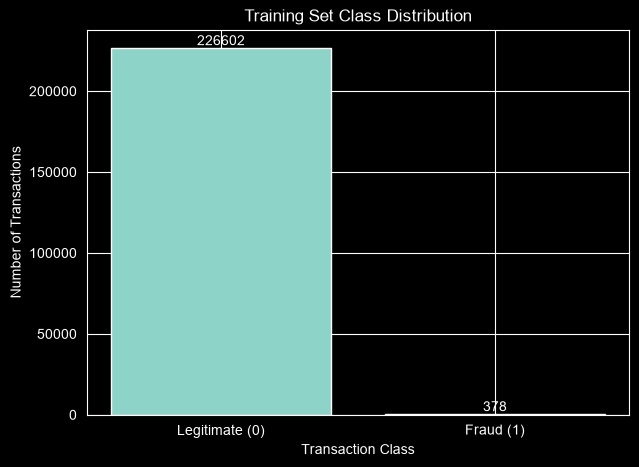

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))

class_counts = y_train.value_counts().sort_index()

bars = plt.bar(
    ["Legitimate (0)", "Fraud (1)"],
    class_counts.values
)

plt.title("Training Set Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.show()

## 12. Save the Feature Scaler

The trained application must apply the same feature transformation
used during model training.

We therefore save the fitted `StandardScaler`.

The scaler was fitted only on the training data, so the saved object
does not contain information learned from the held-out test set.

In [36]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

joblib.dump(
    scaler,
    models_dir / "scaler.pkl"
)

print("Scaler saved successfully!")
print("Location:", models_dir / "scaler.pkl")

Scaler saved successfully!
Location: ..\models\scaler.pkl


## 13. Verify Saved Preprocessing Object

We reload the saved scaler to verify that the preprocessing object can
be successfully restored for future model inference.

In [37]:
loaded_scaler = joblib.load("../models/scaler.pkl")

print("Scaler loaded successfully!")
print("Scaler type:", type(loaded_scaler).__name__)

Scaler loaded successfully!
Scaler type: StandardScaler


## 14. Save the Train-Test Split

The cleaned dataset has already been split into training and held-out
test sets using stratification.

We save the split so that future model experiments use exactly the same
observations.

The held-out test set will remain untouched during model selection and
threshold optimization.

In [38]:
split_data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}

joblib.dump(
    split_data,
    "../models/train_test_split.pkl"
)

print("Train-test split saved successfully!")
print("Location: ../models/train_test_split.pkl")

Train-test split saved successfully!
Location: ../models/train_test_split.pkl


## 15. Final Preprocessing Verification

Before moving to model experimentation, we perform a final validation
of the prepared dataset and train-test split.

The held-out test set must remain separate from model training and
contain both legitimate and fraudulent transactions.

In [39]:
print("===== FINAL PREPROCESSING CHECK =====")

print("\nOriginal cleaned dataset:")
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nTraining set:")
print("Rows:", len(X_train))
print("Features:", X_train.shape[1])
print("Fraud cases:", (y_train == 1).sum())
print("Legitimate cases:", (y_train == 0).sum())

print("\nHeld-out test set:")
print("Rows:", len(X_test))
print("Features:", X_test.shape[1])
print("Fraud cases:", (y_test == 1).sum())
print("Legitimate cases:", (y_test == 0).sum())

print("\nScaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Duplicate rows: 0

Training set:
Rows: 226980
Features: 30
Fraud cases: 378
Legitimate cases: 226602

Held-out test set:
Rows: 56746
Features: 30
Fraud cases: 95
Legitimate cases: 56651

Scaled training shape: (226980, 30)
Scaled test shape: (56746, 30)
